# Title 

## 1. Introduction 

### <u> a. Background Information </u>
- provide some relevant background information on the topic so that someone unfamiliar with it will be prepared to understand the rest of your report

### <u> b. Question </u>

For our project, we will be addressing broad question #1: **What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?**

The specific question we have formulated to investigate: **Are age and played_hours predictors of the subscription status of a game-related newsletter?**


### <u> c. Data Description </u>

We are using only 1 (players.csv) of the 2 datasets provided, as only 1 is necessary to answer our question. 

#### **Players**

- total 7 variables
- total 196 observations (participants)
- one of the Age observations contains an "NA"

  
| Variable  | Data Type | Meaning|
| --------- | --------- |--------|
|experience | chr  |participant level of experience in Minecraft (Beginner, Amateur, Regular, Veteran,Pro)| 
|subscribe  |  lgl |whether or not (True/False) participant is subscribed to game-related newsletter|
|hashedEmail|chr|participant email that has been hashed |
| played_hours| dbl |hours played in Minecraft  |
|name  |   chr  |  Participant name |
|gender|chr|Gender of participant |
|Age | dbl |participant age|

- **Issues**
    1. variable name hashedEmail is not in snake_case
    2. Age variable is not in snake_case (very small issue, however, inconsistent)
    3. "NA" in Age variable 
       

## Methods & Results 

- describe the methods you used to perform your analysis from beginning to end that narrates the analysis code.
- your report should include code which:
  
- terence 
    - loads data
    - wrangles and cleans the data to the format necessary for the planned analysis
    - performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis
    - creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis

together (plan a call in future): 

    - performs the data analysis
    - creates a visualization of the analysis
    - note: all figures should have a figure number and a legend


3. Exploratory Data Analysis

Firstly, the *repr* and *tidyverse* package is loaded into jupyter for obtaining the tools necessary for data analysis and wrangling.

In [1]:
library(repr)
library(tidyverse)
options(repr.matrix.max.rows = 5) #limited dataframes to only show the first 5 rows for legibility

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,played_hours,name,gender,Age
<chr>,<lgl>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,30.3,Morgan,Male,9
Veteran,TRUE,3.8,Christian,Male,17
Veteran,FALSE,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,2.3,Harlow,Male,17
Pro,TRUE,0.2,Ahmed,Other,NA


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


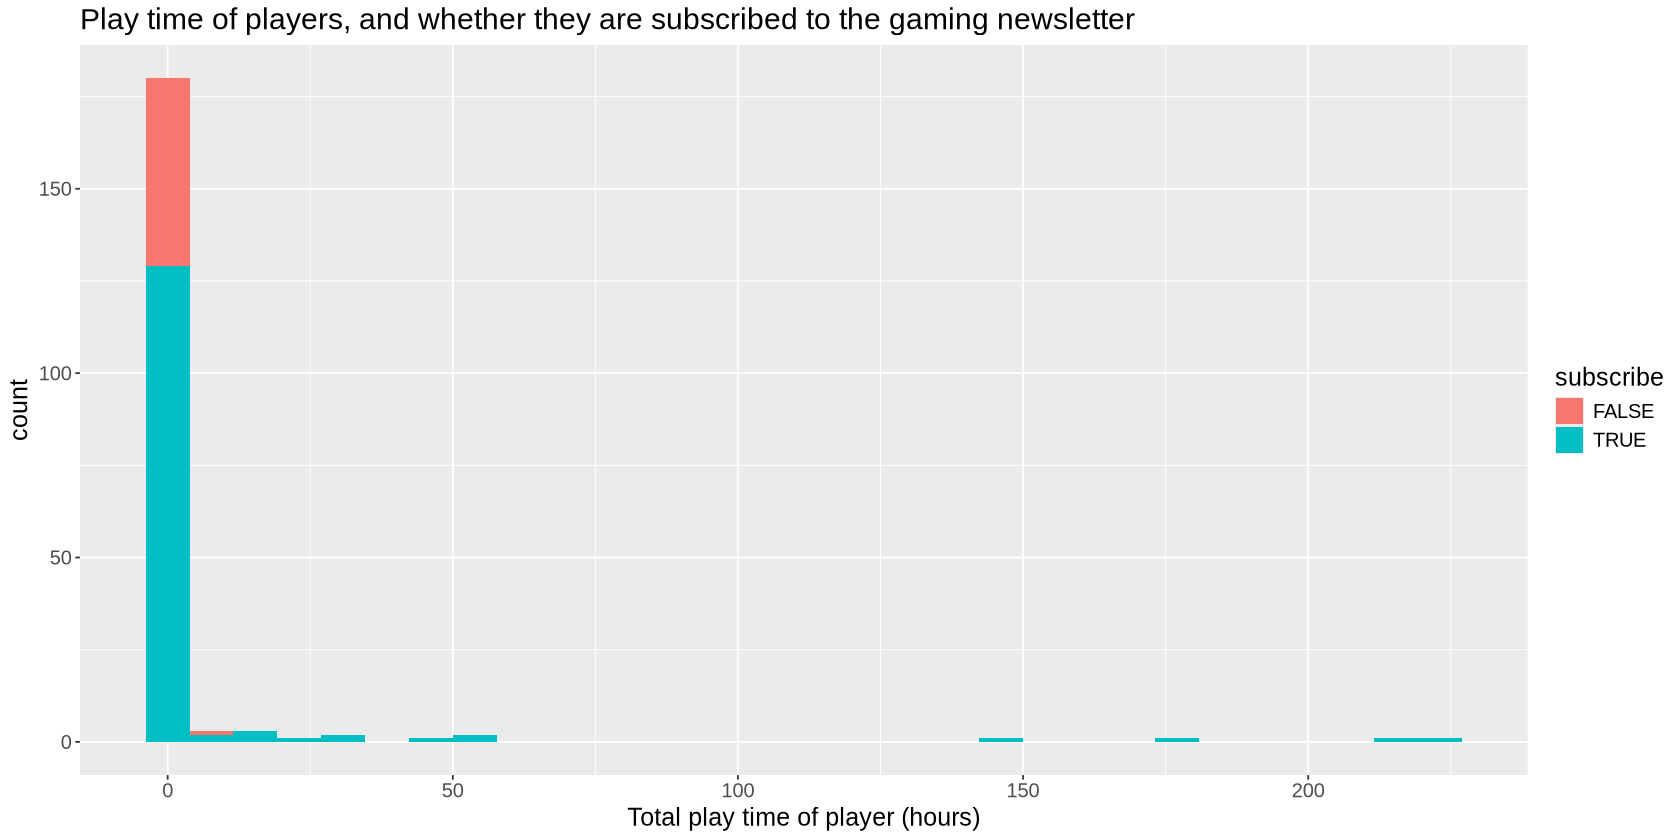

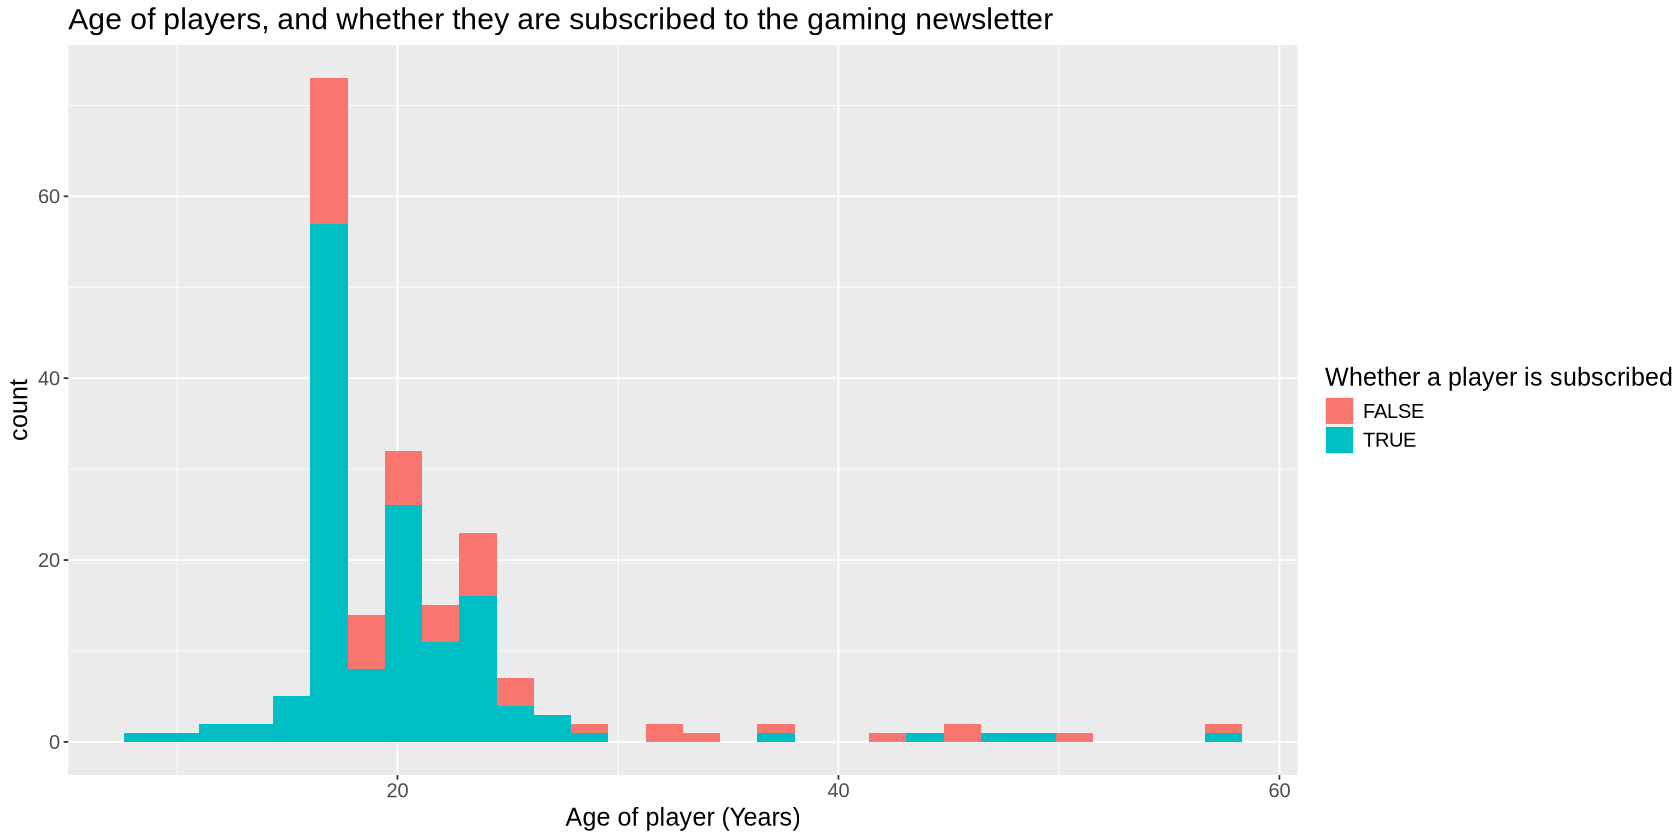

In [2]:
sessions <- read_csv("data/sessions.csv")
players <- read_csv("data/players.csv") |>
    select(-hashedEmail)
players
options(repr.plot.height=7, repr.plot.width=14)
players_hrs_vis <- players |>
    mutate(subscribe=as_factor(subscribe)) |>
    ggplot(aes(x=played_hours, fill= subscribe)) +
    geom_histogram() +
    labs(x= "Total play time of player (hours)", color= "Whether a player is subscribed", title = "Play time of players, and whether they are subscribed to the gaming newsletter") +
    theme(text = element_text(size=15))
players_hrs_vis
players_age_vis <- players |>
    ggplot(aes(x=Age, fill= subscribe)) +
    geom_histogram() +
    labs(x= "Age of player (Years)", fill= "Whether a player is subscribed", title = "Age of players, and whether they are subscribed to the gaming newsletter") +
    theme(text = element_text(size=15))
players_age_vis

experience,subscribe,played_hours,name,gender,Age
<chr>,<lgl>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,30.3,Morgan,Male,9
Veteran,TRUE,3.8,Christian,Male,17
Amateur,TRUE,0.7,Flora,Female,21
⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,2.3,Harlow,Male,17
Pro,TRUE,0.2,Ahmed,Other,NA


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


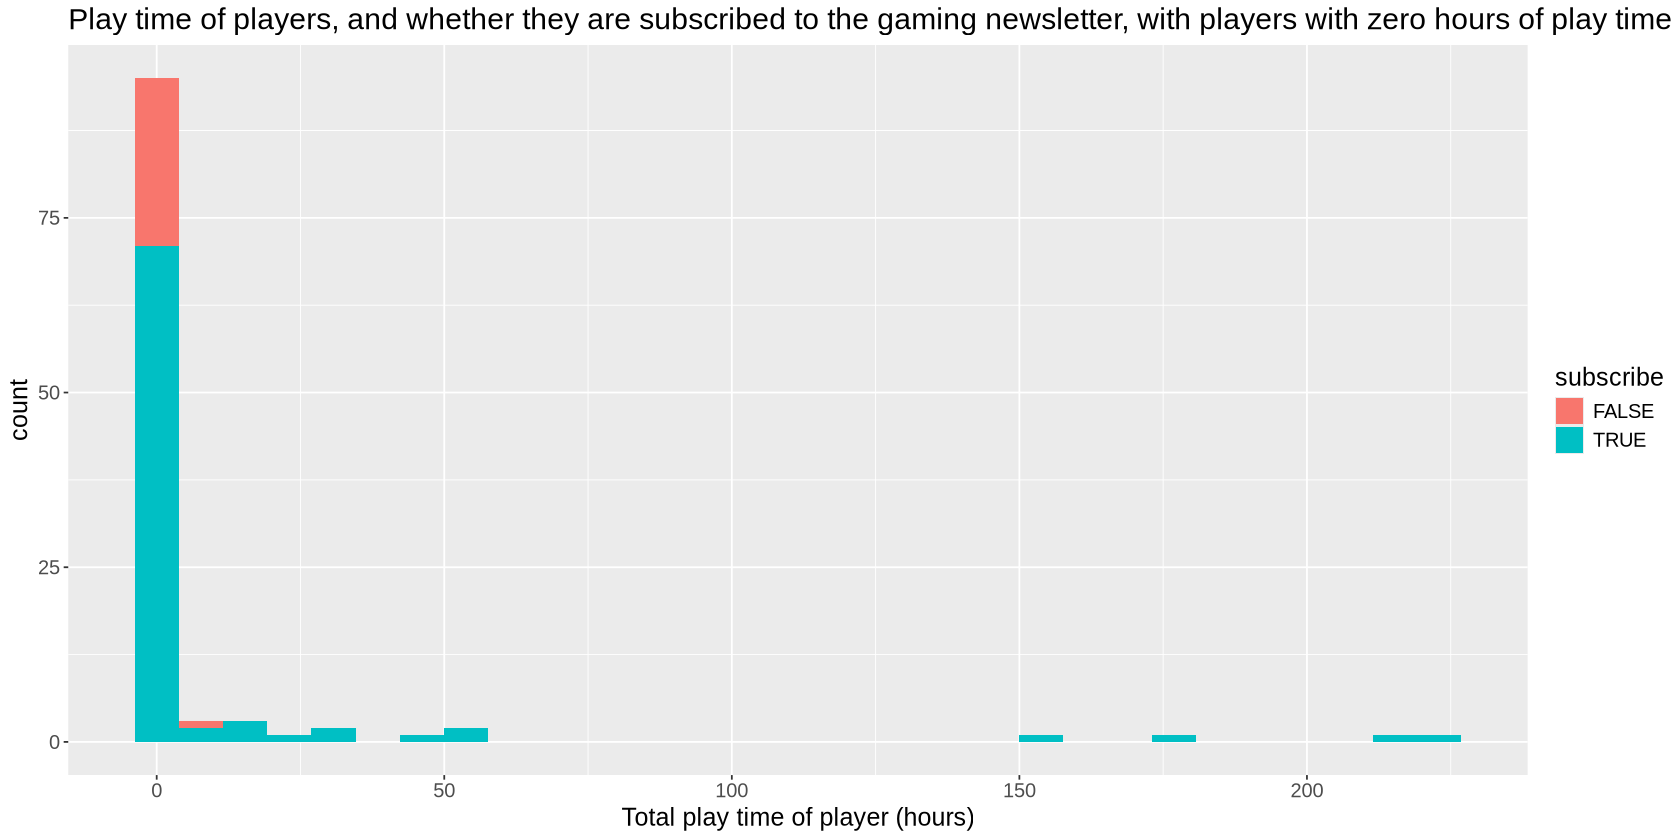

In [8]:
players_filtered <- players |>
    filter(played_hours > 0.0)
players_filtered
players_hrs_vis_2 <- players_filtered |>
    ggplot(aes(x=played_hours, fill= subscribe)) +
    geom_histogram() +
    labs(x= "Total play time of player (hours)", color= "Whether a player is subscribed", title = "Play time of players, and whether they are subscribed to the gaming newsletter, with players with zero hours of play time removed") +
    theme(text = element_text(size=15))
players_hrs_vis_2

Don't know how to automatically pick scale for object of type <function>.
Defaulting to continuous.
ERROR while rich displaying an object: Error in `geom_bar()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error in `compute_aesthetics()`:
! Aesthetics are not valid data columns.
✖ The following aesthetics are invalid:
✖ `y = count`
ℹ Did you mistype the name of a data column or forget to add `after_stat()`?

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!

## Discussion 
- chloe: summarize what you found
- merry: discuss whether this is what you expected to find
- terence: discuss what impact could such findings have
- wendy: discuss what future questions could this lead to



## References 
You may include references if necessary, as long as they all have a consistent citation style.